In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler

# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = ['#0047AB',  '#FF0000',  '#00CC00',  '#9932CC',  '#FF8C00',  '#FF00FF',  '#FFD700',  '#00CED1',  '#FF4500',  '#7FFF00']

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False             # Add caps to error bars
})

# Exercise 08

The variational principle in Quantum Mechanics states that the expectation value of the Hamiltonian over a (good) trial quantum state has the ground state energy $E_0$ as lower bound:

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}

{\int dx |\Psi_T(x)|^2} \ge E_0 =
\frac{\langle \Psi_0| {\hat H} | \Psi_0 \rangle}
{\langle \Psi_0 | \Psi_0 \rangle}
$$

During this exercise I will variationally optimize the ground state of a single quantum particle in a one dimensional (1D) space confined by the following external potential:
$$
V(x) = x^4 - \frac{5}{2}x^2
$$

This 1D quantum model is not analytically solvable and should be attacked by numerical methods. In order to obtain an approximate wave function for the ground state, the Variational Monte Carlo method uses a trial wave function, parametrized by a set of variational parameters. An approximate model for the ground state wave function is the following trial wave function:
$$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$

$\Psi_T^{\sigma,\mu}(x)$ depends on two variational parameters: </span> ${\sigma}$ and </span> ${\mu}$.

## Exercise 08.1
### Assignment

Write a Variational Monte Carlo code for a single quantum particle in 1D which exploits the Metropolis algorithm to sample the square modulus of our trial wave function $|\Psi_T^{\sigma,\mu}(x)|^2$ using an uniform transition probability $T(x_{new}|x_{old})$. By using data blocking, the code should be able to compute the expectation value for the Hamiltonian

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
$$

which can be used to find the parameters that minimize this quantity. Use $\hbar = 1$ and $m=1$.
Note that to measure ${\langle {\hat H} \rangle_T}$ you need the analytical calculation of:
    
$$
\frac{{-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)}
$$

### Solution

I have written a Variational Monte Carlo code for a single quantum particle in 1D which samples the square modulus of our trial wave function $|\Psi_T^{\sigma,\mu}(x)|^2$ using an uniform transition probability $T(x_{new}|x_{old})$. The parameters $\hbar = 1$ and $m=1$ have been used, along with the analytical calculation of:

$$
\frac{{-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)} = [...] = \frac{\partial^2 \Psi_T(x)}{\partial x^2} = \left( \frac{(x-\mu)^2}{\sigma^4} - \frac{1}{\sigma^2} \right) e^{-\frac{(x-\mu)^2}{2\sigma^2}} + \left( \frac{(x+\mu)^2}{\sigma^4} - \frac{1}{\sigma^2} \right) e^{-\frac{(x+\mu)^2}{2\sigma^2}} 
$$

### Code architecture

1. **Simulated Annealing (SA):** 
    Before running the actual measurement, we need to find the optimal set of parameters $(\mu, \sigma)$ that minimizes the energy $E_{VMC}$. To do this, we treat the energy expectation value as a cost function in the parameter space and apply a **Simulated Annealing** algorithm.
    * **Fictitious Temperature:** We introduce an artificial temperature $T$ that slowly decreases over time (cooling schedule).
    * **Metropolis Exploration:** At each temperature step, the algorithm proposes a random shift in $\mu$ and $\sigma$. The new configuration is accepted with a Boltzmann-like probability $p = \min(1, e^{-\beta \Delta E})$. 
    * This stochastic approach prevents the system from getting trapped in local minima, allowing an ergodic exploration of the parameter space until it "freezes" into the global minimum.

2. **Data Blocking & Sampling:**
    Once the optimized parameters are found, we launch the core VMC simulation to evaluate the integral for the ground state energy and to sample the spatial configurations.
    * **Metropolis-Hastings Algorithm:** A Markov Chain is generated to sample the particle's positions $x$ distributed according to the probability density function $p(x) = \frac{|\Psi_T(x)|^2}{\int |\Psi_T(x)|^2 dx}$.
    * **Local Energy:** At each accepted step, the code evaluates the local energy $E_{loc}(x) = \frac{\hat{H}\Psi_T(x)}{\Psi_T(x)}$, which includes both the kinetic term (computed analytically via the second derivative of the trial function) and the potential term $V(x)$.
    * **Data Blocking Technique:** Since the spatial configurations generated by the Metropolis algorithm are highly correlated, evaluating the statistical uncertainty using a standard standard deviation would be mathematically incorrect. We implement the **data blocking** method to group the steps into independent blocks, safely removing autocorrelations and providing a reliable estimation of the statistical error on the final ground state energy.

Here is shown the data of a simulation of $1\times 10^3$ blocks and $1\times 10^4$ steps. First, I report the acceptance to verify that it approaches 0.5, then the value of the integral is plotted as a function of the number of blocks. 

The main for this exercise is saved in NSL_SIMULATOR_old_08.1.cpp. To use it, it is necessary to modify the makefile.


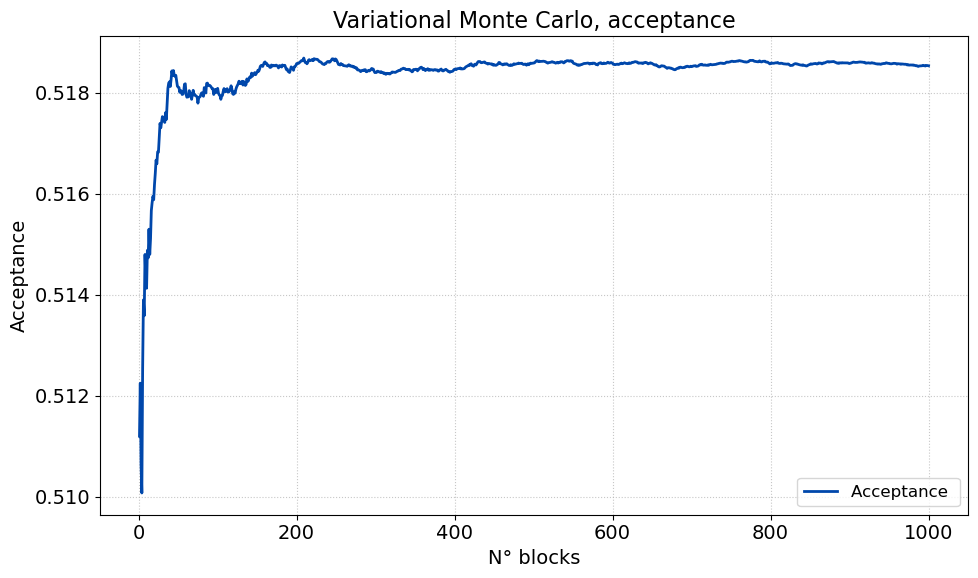

In [2]:
acceptance = np.loadtxt("NSL_SIMULATOR/OUTPUT_08.1/acceptance.dat")

plt.plot(acceptance[:, 0], acceptance[:, 1], label='Acceptance ')

# Graphic elements
plt.title("Variational Monte Carlo, acceptance")
plt.xlabel('N° blocks')
plt.ylabel('Acceptance')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

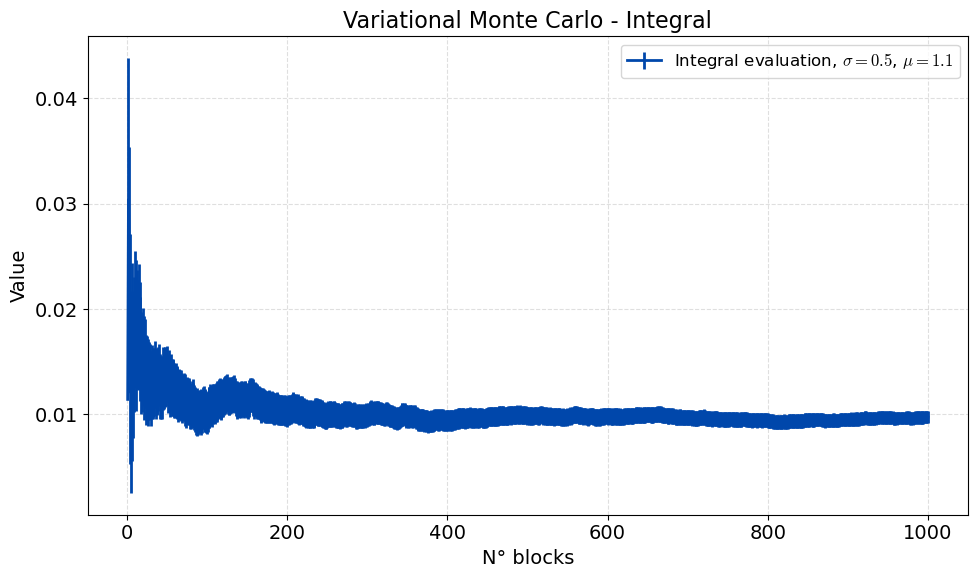

In [3]:
integral = np.loadtxt("NSL_SIMULATOR/OUTPUT_08.1/integral.dat")

plt.errorbar(integral[:, 0], integral[:, 2], integral[:, 3], label=r'Integral evaluation, $\sigma = 0.5$, $\mu = 1.1$')

# Graphic elements
plt.title("Variational Monte Carlo - Integral")
plt.xlabel('N° blocks')
plt.ylabel('Value')
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

### Exercise 08.2

Here I implement the Monte Carlo method also for the parameters $\mu$ and $\sigma$.

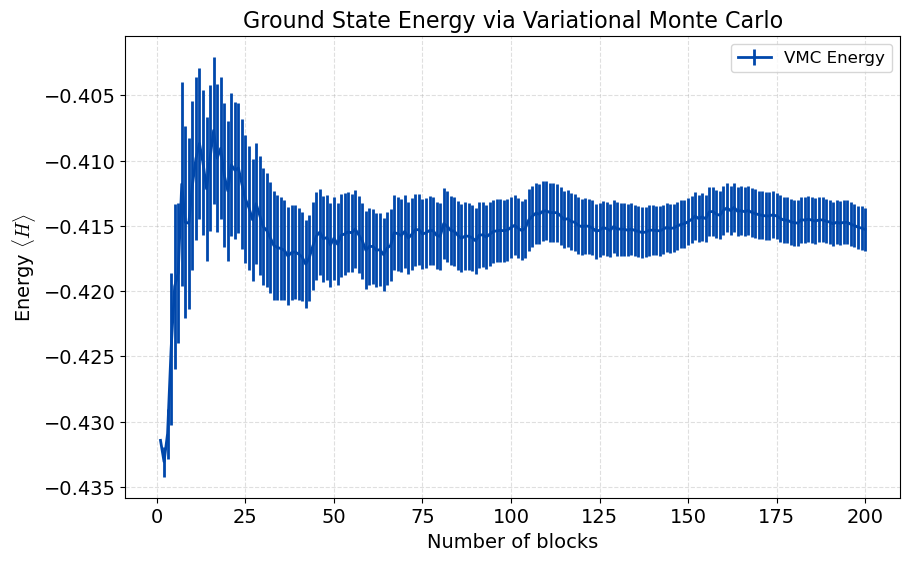

In [4]:
integral = np.loadtxt("NSL_SIMULATOR/OUTPUT/integral.dat")

plt.figure()
plt.errorbar(integral[:, 0], integral[:, 2], yerr=integral[:, 3], color=light_colors[0], label='VMC Energy')
plt.title('Ground State Energy via Variational Monte Carlo')
plt.xlabel('Number of blocks')
plt.ylabel(r'Energy $\langle H \rangle$')
plt.grid(True)
plt.legend()
plt.show()


The Variational Monte Carlo (VMC) estimation of the ground state energy successfully converges to a stable value. As expected from the Variational Principle, the optimized energy is an upper bound to the exact numerical solution. The statistical uncertainties, evaluated through the data blocking method, remain under control and scale correctly with the number of blocks.

In [5]:
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

print("Ground state energy: ", E[0])
print("1st excited state energy: ", E[1])
print("2nd excited state energy: ", E[2])


Ground state energy:  -0.46046587969271535
1st excited state energy:  0.09742471331761199
2nd excited state energy:  1.971733134393021


-------- OPTIMIZED PARAMETERS --------

sigma = 0.685542
mu =  0.78504

BEST ENERGY FOUND ====>  -0.412227


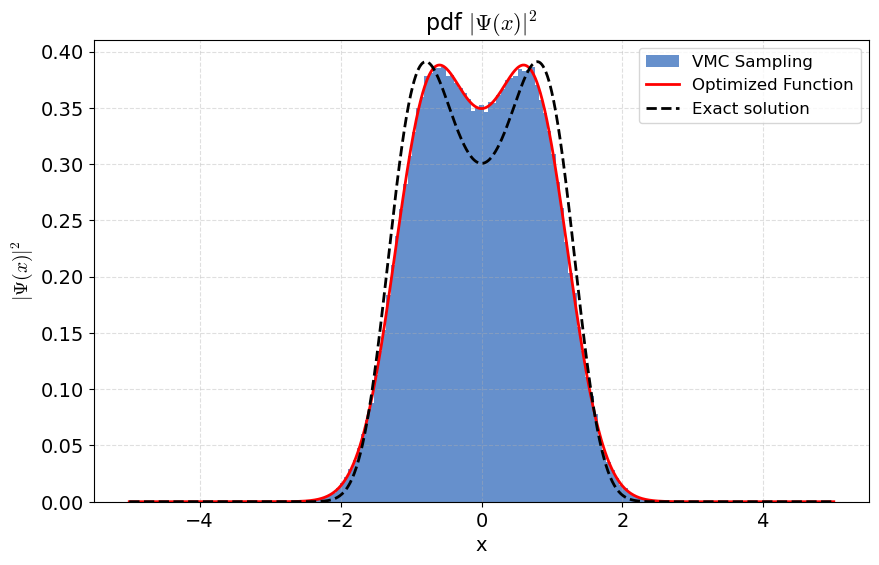

In [6]:
# Load sampled points
posizioni = np.loadtxt("NSL_SIMULATOR/OUTPUT/positions.dat") 
plt.figure()

# Histogram
plt.hist(posizioni, bins=100, density=True, alpha=0.6, label='VMC Sampling')

# Optimized parameters
parametri = np.loadtxt("NSL_SIMULATOR/OUTPUT/optimized_params.dat")

sigma = parametri[0]
mu = parametri[1]
energia_minima = parametri[2]

print('-------- OPTIMIZED PARAMETERS --------\n')
print('sigma =', sigma)
print('mu = ', mu)
print()
print('BEST ENERGY FOUND ====> ', energia_minima)

# Trial function
psi_trial = np.exp(-(x-mu)**2 / (2*sigma**2)) + np.exp(-(x+mu)**2 / (2*sigma**2))
# Norm
norm = np.trapezoid(psi_trial**2, x)
pdf_analitica = (psi_trial**2) / norm

plt.plot(x, pdf_analitica, linewidth=2, label='Optimized Function')
plt.plot(x, (psi[0])**2, color='k', linestyle='--', label="Exact solution")

plt.title(r'pdf $|\Psi(x)|^2$')
plt.xlabel('x')
plt.ylabel(r'$|\Psi(x)|^2$')
plt.legend()
plt.grid(True)
plt.show()

The spatial configurations sampled by the Metropolis algorithm show an excellent agreement with the analytical curve generated using the optimized parameters $(\mu, \sigma)$. The slight discrepancy between our VMC result and the exact matrix diagonalization is not a statistical error, but rather a structural limitation of the chosen trial wave function (a superposition of two Gaussians), which cannot perfectly mimic the true ground state of this specific double-well potential.

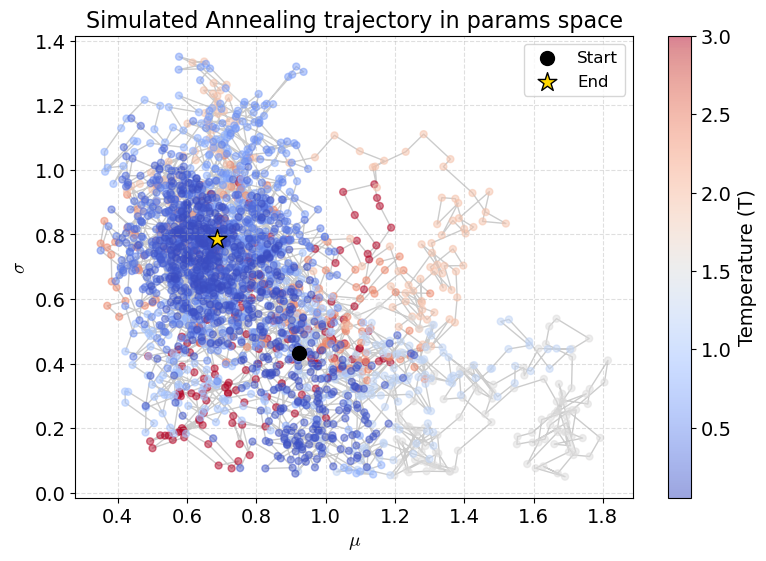

/tmp/ipykernel_88585/2250449135.py:40: UserWarning: Adding colorbar to a different Figure <Figure size 900x600 with 3 Axes> than <Figure size 1200x800 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(sc)


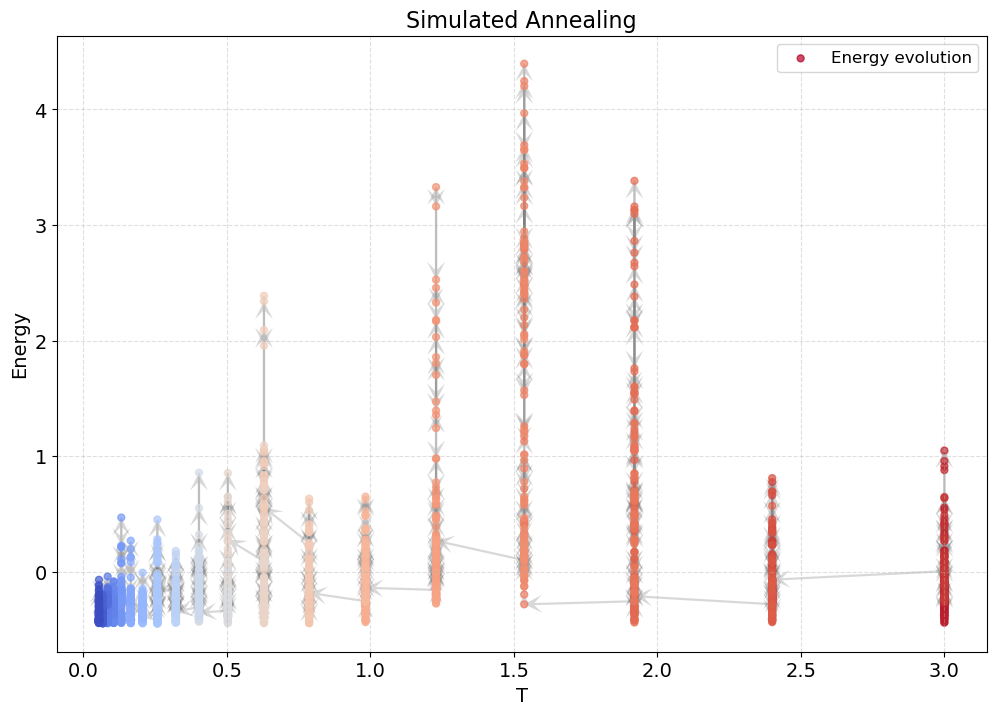

In [26]:
# Carica i dati della traiettoria
# Colonna 0: mu, Colonna 1: sigma, Colonna 2: energia, Colonna 3: temperatura
dati_traj = np.loadtxt("NSL_SIMULATOR/OUTPUT/trajectory.dat")

mu_traj = dati_traj[:, 0]
sigma_traj = dati_traj[:, 1]
energia_traj = dati_traj[:, 2]
temp_traj = dati_traj[:, 3]

sel_cmap = 'coolwarm'

plt.figure(figsize=(9, 6))

# line
plt.plot(mu_traj, sigma_traj, color='gray', alpha=0.4, linewidth=1.0, zorder=1)

# Scatter plot con gradiente di colore basato sulla temperatura
sc = plt.scatter(mu_traj, sigma_traj, c=temp_traj, cmap=sel_cmap, marker='.', s=100, alpha=0.5)

cbar = plt.colorbar(sc)
cbar.set_label('Temperature (T)')

# Segniamo il punto di partenza e il punto di arrivo (minimo trovato)
plt.scatter(mu_traj[0], sigma_traj[0], color='black', s=100, marker='o', label='Start')
plt.scatter(mu_traj[-1], sigma_traj[-1], color='gold', s=200, marker='*', edgecolor='black', label='End')
plt.title('Simulated Annealing trajectory in params space')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.show()


# line
plt.figure(figsize=(12, 8))
order = np.linspace(100, 1, len(temp_traj))
plt.quiver(temp_traj[:-1], energia_traj[:-1], np.diff(temp_traj), np.diff(energia_traj), 
           angles='xy', scale_units='xy', scale=1, color='grey', linewidth=0.5, headlength=8 , headwidth =8, zorder=1, alpha = 0.3)

plt.scatter(temp_traj, energia_traj, c=order,  cmap=sel_cmap, label='Energy evolution', alpha = 0.7)
cbar = plt.colorbar(sc)
cbar.set_label('Temperature (T)')
plt.title('Simulated Annealing')
plt.xlabel('T')
plt.ylabel('Energy')
plt.legend()
plt.show()

Looking at the trajectory it is possible to appreciate the strenght of this algorithm: at the beginning the high temperature enables it to explore a vast region of the phase space. Later, when the temperature drops, it gets more and more precise in the minimum it has found. 